# Project — Tensor-train analysis of a star-shaped graphene flake

In this notebook I study a star-shaped graphene flake using quantics / tensor-train methods. The starting point is the sparse Hamiltonian $H$ together with a localized trial density matrix $\rho_{\mathrm{trial}}$. From these objects, I construct tensor-train representations, analyze their bond dimensions, and explore how the complexity of the Hamiltonian grows with the flake size.

A central part of the notebook is the construction of the commutator
$$
[H,\rho] = H\rho - \rho H,
$$
both as a direct tensor-train approximation and through MPO-style operator algebra. Finally, as a supplementary illustration of the physical motivation behind these constructions, I include a small-scale real- and imaginary-time evolution on a moderate-size flake.

In [1]:
Base.active_project()

"/home/paula/proyectos/mi_primer_julia/Project.toml"

In [2]:
using Quantica
using QuanticsTCI
using LinearAlgebra, SparseArrays
using CairoMakie
using Random
import TensorCrossInterpolation as TCI

Random.seed!(1234)

TaskLocalRNG()

In [3]:
R0 = 376.0
shape(r) = norm(r) < R0 * (1 + 0.2*cos(5*atan(r[2], r[1])))

h_model = LatticePresets.honeycomb() |>
    hopping(1) |>
    supercell(region = shape)

Hamiltonian{Float64,2,0}: Hamiltonian on a 0D Lattice in 2D space
  Bloch harmonics  : 1
  Harmonic size    : 1046212 × 1046212
  Orbitals         : [1, 1]
  Element type     : scalar (ComplexF64)
  Onsites          : 0
  Hoppings         : 3134940
  Coordination     : 2.99647

In [4]:
ρ_model = LatticePresets.honeycomb() |>
    @onsite(i --> ifelse(ind(i) == 1, 1, 0)) |>
    supercell(region = shape)

ParametricHamiltonian{Float64,2,0}: Parametric Hamiltonian on a 0D Lattice in 2D space
  Bloch harmonics  : 1
  Harmonic size    : 1046212 × 1046212
  Orbitals         : [1, 1]
  Element type     : scalar (ComplexF64)
  Onsites          : 1046212
  Hoppings         : 0
  Coordination     : 0.0
  Parameters       : Symbol[]

## 1. Construction of $H$ and $\rho_{\mathrm{trial}}$

We use exactly the geometry proposed in the assignment. For the main case we take `R0 = 376`, which produces a flake with about $10^6$ sites.

In [5]:
H = h_model(())
ρ_trial = ρ_model(())

@show size(H)
@show size(ρ_trial)
@show nnz(H)
@show nnz(ρ_trial)


size(H) = (1046212, 1046212)
size(ρ_trial) = (1046212, 1046212)
nnz(H) = 3134940
nnz(ρ_trial) = 1046212


1046212

For `R0 = 376`, the flake should contain approximately `1046212` sites. The Hamiltonian is obtained as `H = h_model(())`, and the trial matrix as `ρ_trial = ρ_model(())`.

The main objective is to build TT/QTT representations of these padded operators, measure their bond dimensions, and then construct the commutator $[H,\rho]$.

## Geometry of the star-shaped flake

Before constructing the tensor-train representations, it is useful to visualize the boundary of the star-shaped region used to define the graphene flake. For clarity, the plot below shows the same shape for a smaller value of $R_0$.

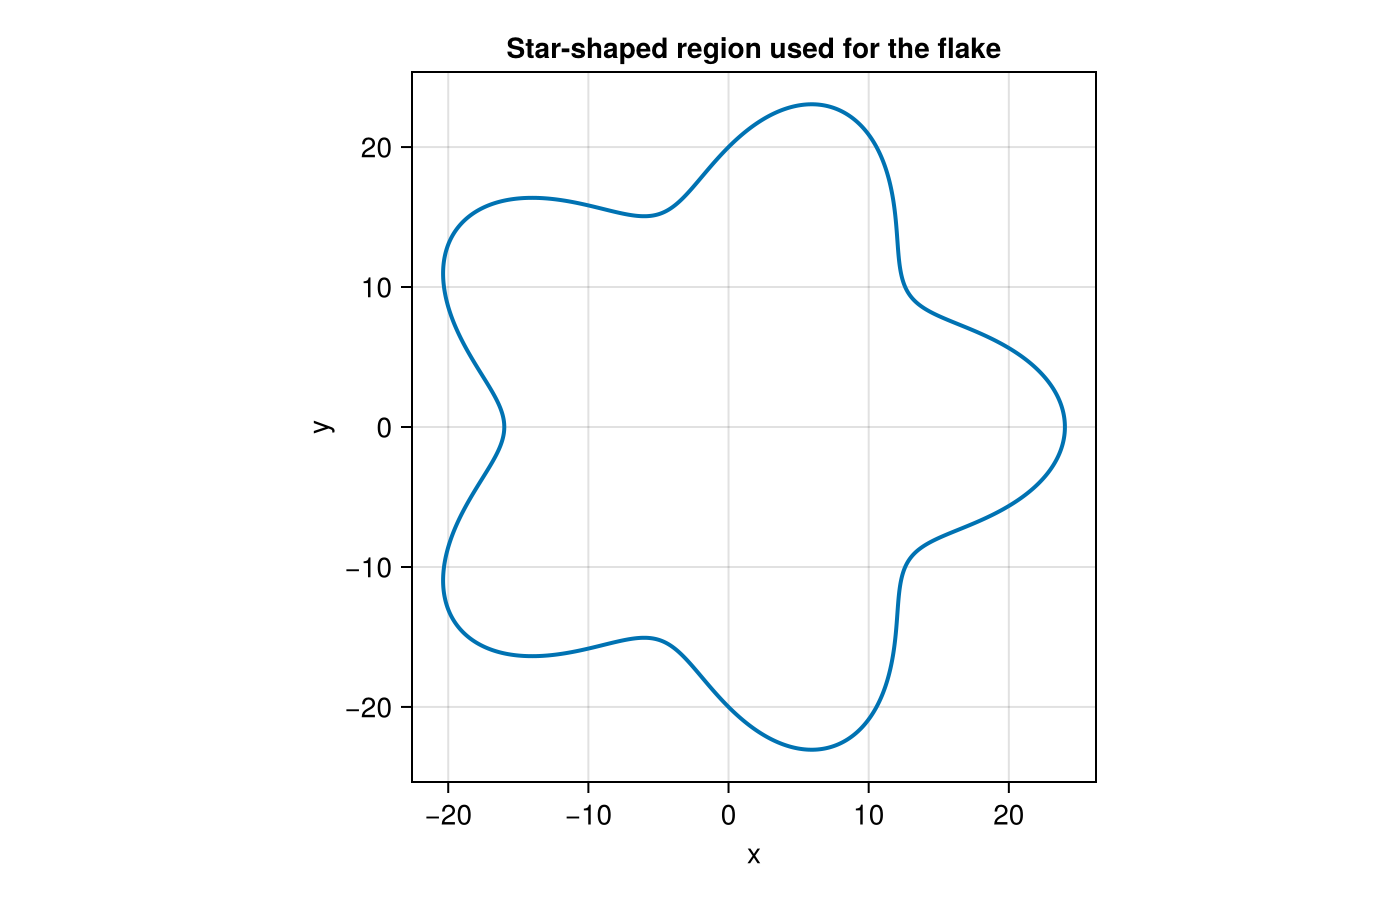

In [7]:
function starfish_boundary(R0; npts = 1000)
    θ = range(0, 2π; length = npts)
    r = R0 .* (1 .+ 0.2 .* cos.(5 .* θ))
    x = r .* cos.(θ)
    y = r .* sin.(θ)
    return x, y
end

R0_demo = 20.0
xB, yB = starfish_boundary(R0_demo)

fig = Figure(size = (700, 450))
ax = Axis(
    fig[1, 1],
    xlabel = "x",
    ylabel = "y",
    title = "Star-shaped region used for the flake",
    aspect = DataAspect(),
)
lines!(ax, xB, yB, linewidth = 2)
fig

## Objectives

- Construction of the tensor-train (QTT / TT-operator) representation of $H$ and $\rho_{\mathrm{trial}}$ with train length $L = 20$.
- Embedding both matrices into size $2^{20} \times 2^{20}$ by padding with zeros outside the physical range.
- Study of their bond dimensions.
- Study how the bond dimension changes with the flake size parameter `R0`.
- Construction of the commutator $[H,\rho]$ and compression in TT/MPO form.
- A final supplementary section illustrates how these objects are connected to real- and imaginary-time evolution.


## Tools used in this notebook

- **Quantica.jl** is used to construct the graphene flake and obtain the sparse Hamiltonian $H$.
- **QuanticsTCI.jl** is used to build quantics / TT approximations by cross interpolation.
- **TensorCrossInterpolation.jl** is used for TT/MPO operations such as contraction, subtraction, compression, and inspection of link dimensions.

The notebook follows two related representations:
a blocked QTT ordering for direct approximation and bond-dimension inspection, and an interleaved ordering for MPO-style operator algebra.

## 2. Inspecting the sparse matrices

In [8]:
H[1:20, 1:20] |> Matrix

20×20 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0

In [9]:
ρ_trial[1:20, 1:20] |> Matrix

20×20 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0

The matrix `ρ_trial` is a highly localized object: it contains a single physical `1` at the first diagonal entry, although the sparse representation returned by `Quantica` still stores many zero entries on the diagonal. In practice, it behaves as a delta-like projector.

In [10]:
@show size(H)
@show nnz(H)
@show eltype(H)

size(H) = (1046212, 1046212)
nnz(H) = 3134940
eltype(H) = ComplexF64


ComplexF64 (alias for Complex{Float64})

In [11]:
ρ_nz = Quantica.dropzeros(ρ_trial)

@show size(ρ_trial)
@show nnz(ρ_trial)
@show eltype(ρ_trial)
@show nnz(ρ_nz)
@show ρ_nz[1,1]

size(ρ_trial) = (1046212, 1046212)
nnz(ρ_trial) = 1046212
eltype(ρ_trial) = ComplexF64
nnz(ρ_nz) = 1
ρ_nz[1, 1] = 1.0 + 0.0im


1.0 + 0.0im

In [12]:
@show nnz(dropzeros(H))
@show nnz(dropzeros(ρ_trial))

nnz(dropzeros(H)) = 3134940
nnz(dropzeros(ρ_trial)) = 1


1

The sparsity pattern is consistent with the physics of the problem:

- `nnz(H) ≈ 3N`, which matches the fact that each site in graphene has approximately three neighbors.
- `dropzeros(ρ_trial)` leaves a matrix with a single nonzero entry, so $\rho_{\mathrm{trial}}$ is effectively a localized delta projector.

In [13]:
N = size(H, 1)  # 1046212
L = ceil(Int, log2(N)) # 20 (log2(N) es 19.9... ∼ 20)
M = 1 << L ; # 1 << 20 == 2^20 = 1048576 (2^L , it is the quantized size)
@show N
@show L
@show M

N = 1046212
L = 20
M = 1048576


1048576

In [ ]:
fH(i,j) = (1 <= i <= N && 1 <= j <= N) ? H[i,j] : zero(eltype(H))
fρ_trial(i,j) = (1 <= i <= N && 1 <= j <= N) ? ρ_trial[i,j] : zero(eltype(ρ_trial))

# fH es acceso seguro a la matriz H: 1º evalúa la condición de si i y j están dentro del rango 1...N, 2º si sí devuelve H[i,j], si no devuelve 0.0
# ? : es el operador ternario == condicion ? valor_si_true : valor_si_false

fρ_trial (generic function with 1 method)

## 3.  Padding to size $2^L \times 2^L$

Quantics / TCI methods are naturally formulated on a complete binary grid. Since the physical matrix size $N$ is not exactly a power of two, both operators are embedded into a larger matrix of size
$$
M \times M, \qquad M = 2^L, \qquad L = \lceil \log_2 N \rceil .
$$
All entries outside the physical range $1 \le i,j \le N$ are set to zero.

The interpolation routine does not query matrix entries directly as $H[i,j]$. Instead, it works with a binary multi-index of length $2L$. The first $L$ bits encode the row index $i$, and the next $L$ bits encode the column index $j$. Therefore, the key step is to define an evaluator that maps a bit string to the corresponding padded matrix entry.

In [15]:
function bits_to_int(bits)
    x = 0
    for b in bits
        bb = (b >= 0.5) ? 1 : 0
        x = (x << 1) | bb
    end
    return x
end

function int_to_bitvals(k::Int, L::Int)
    k0 = k - 1
    bits = Vector{Float64}(undef, L)
    for t in 1:L
        shift = L - t
        bits[t] = ((k0 >> shift) & 1) == 1 ? 1.0 : 0.0
    end
    return bits
end

bitvals_to_pivot(bits) = [b == 0.0 ? 1 : 2 for b in bits]

bitvals_to_pivot (generic function with 1 method)

## 4. QTT of $H$ and $\rho_{\mathrm{trial}}$ in blocked ordering

I first build the quantics representation in the order

$$
(i_1,\dots,i_L, j_1,\dots,j_L),
$$

that is, all row bits first and all column bits afterward.

In TT/QTT form, matrix indices are represented in binary. The evaluator therefore converts a $2L$-bit input into the pair $(i,j)$, and then returns the corresponding padded matrix entry.

In [16]:
function H_quantics(x...)
    @assert length(x) == 2L
    i0 = bits_to_int(x[1:L])
    j0 = bits_to_int(x[L+1:2L])
    return fH(i0 + 1, j0 + 1)
end

H_quantics (generic function with 1 method)

If we try to build the QTT of a very sparse matrix directly, `quanticscrossinterpolate` may fail with the message `maxsamplevalue is zero!`. The reason is that the first randomly sampled pivots can all hit zero entries.

To avoid this, we explicitly provide an initial pivot corresponding to a true nonzero entry of the sparse matrix.

In [17]:
function first_nonzero_entry(A::SparseMatrixCSC)
    for j in 1:size(A,2)
        p1 = A.colptr[j]
        p2 = A.colptr[j+1] - 1
        if p1 <= p2
            i = A.rowval[p1]
            v = A.nzval[p1]
            return i, j, v
        end
    end
    error("No nonzero entries found")
end

i0_H, j0_H, v0_H = first_nonzero_entry(H)
@show i0_H j0_H v0_H

bi_H = int_to_bitvals(i0_H, L)
bj_H = int_to_bitvals(j0_H, L)

initialpivots_H = [vcat(bitvals_to_pivot(bi_H), bitvals_to_pivot(bj_H))]

@show H_quantics(vcat(bi_H, bj_H)...)

i0_H = 523109
j0_H = 1
v0_H = 1.0 + 0.0im
H_quantics(vcat(bi_H, bj_H)...) = 1.0 + 0.0im


1.0 + 0.0im

We can now construct the QTT of the padded Hamiltonian.

In [18]:
dom = [[0.0, 1.0] for _ in 1:(2L)]

tth = QuanticsTCI.quanticscrossinterpolate(
    ComplexF64,
    H_quantics,
    dom,
    initialpivots_H;
    tolerance = 1e-8,
    maxbonddim = 200,
    nrandominitpivot = 0,
)

(QuanticsTCI.QuanticsTensorCI2{ComplexF64}(TensorCrossInterpolation.TensorCI2{ComplexF64} with rank 2, DiscretizedGrid{40}(2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2 points), TensorCrossInterpolation.CachedFunction{ComplexF64, BitIntegers.UInt256} with 699 entries), [2, 2, 2], [0.0, 0.0, 0.0])

At this stage, `tth` is a tensor-train (TT / quantics-QTT) approximation of the Hamiltonian $H$, after padding it to a matrix of size $2^L \times 2^L$ with $L=20$.

The algorithm does not evaluate the matrix on the full space of size $2^{2L}$. Instead, it queries only a small subset of entries through cross interpolation. This is precisely the advantage of the method.

For example, when the output shows something like `CachedFunction(... with 699 entries)`, this means that the algorithm evaluated `H_quantics` at only 699 points in order to construct the TT approximation. This is precisely the main advantage of the method: it avoids the exponentially large cost of accessing the full tensor.

In [19]:
function ρ_quantics(x...)
    @assert length(x) == 2L
    i0 = bits_to_int(x[1:L])
    j0 = bits_to_int(x[L+1:2L])
    return fρ_trial(i0 + 1, j0 + 1)
end

ρ_quantics (generic function with 1 method)

In [20]:
ttρ = QuanticsTCI.quanticscrossinterpolate(
    ComplexF64,
    ρ_quantics,
    dom;
    tolerance = 1e-8,
    maxbonddim = 200,
)

(QuanticsTCI.QuanticsTensorCI2{ComplexF64}(TensorCrossInterpolation.TensorCI2{ComplexF64} with rank 1, DiscretizedGrid{40}(2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2 points), TensorCrossInterpolation.CachedFunction{ComplexF64, BitIntegers.UInt256} with 1735 entries), [1, 1, 1], [0.0, 0.0, 0.0])

For $\rho_{\mathrm{trial}}$, the number of sampled evaluations can differ noticeably from the Hamiltonian case. When the output shows something like `CachedFunction(... with 1687 entries)`, this means that the interpolation algorithm evaluated `ρ_quantics` at 1687 points in order to build the TT approximation, rather than exploring the full $2^{40}$ space.

This is still a dramatic reduction in computational cost. The larger number of sampled points is not surprising: $\rho_{\mathrm{trial}}$ is extremely localized, with a single nonzero diagonal entry, so its structure can be harder to detect from random or adaptive probes. By contrast, the Hamiltonian is sparse but contains many more nonzero entries, which makes its structure easier to identify early in the interpolation process.

Therefore, a larger number of cached evaluations does not mean that $\rho_{\mathrm{trial}}$ is physically more complex. It only means that the algorithm required more function calls to reconstruct this highly localized object at the prescribed tolerance. Since the interpolation may use random initialization, the exact number of sampled points can also vary slightly from run to run.

In [21]:
function bond_data_from_qtt(tt)
    cores = tt.tci.sitetensors
    sizes = map(size, cores)
    r_left  = [s[1] for s in sizes]
    n_local = [s[2] for s in sizes]
    r_right = [s[3] for s in sizes]
    internal_ranks = r_right[1:end-1]
    bond_dim = maximum(vcat(r_left, r_right))
    return (; cores, sizes, r_left, n_local, r_right, internal_ranks, bond_dim)
end

bond_data_from_qtt (generic function with 1 method)

In [22]:
@show typeof(tth)
@show propertynames(tth)

typeof(tth) = Tuple{QuanticsTCI.QuanticsTensorCI2{ComplexF64}, Vector{Int64}, Vector{Float64}}
propertynames(tth) = (1, 2, 3)


(1, 2, 3)

`quanticscrossinterpolate` returns a tuple. The actual QTT object is stored in the first component, which is the one relevant for inspecting site tensors and bond dimensions.

In [23]:
ttH = tth[1]
ttρ_trial = ttρ[1]

QuanticsTCI.QuanticsTensorCI2{ComplexF64}(TensorCrossInterpolation.TensorCI2{ComplexF64} with rank 1, DiscretizedGrid{40}(2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2×2 points), TensorCrossInterpolation.CachedFunction{ComplexF64, BitIntegers.UInt256} with 1735 entries)

### Bond-dimension data for H

In [24]:
info_H = bond_data_from_qtt(ttH)

println("Bond data for ttH")
@show length(info_H.cores)
@show info_H.n_local[1:5]
@show info_H.internal_ranks
@show info_H.bond_dim

Bond data for ttH
length(info_H.cores) = 40
info_H.n_local[1:5] = [2, 2, 2, 2, 2]
info_H.internal_ranks = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1]
info_H.bond_dim = 2


2

### Bond-dimension data for $\rho_{\mathrm{trial}}$

In [25]:
info_ρ = bond_data_from_qtt(ttρ_trial)

println("Bond data for ttρ_trial")
@show length(info_ρ.cores)
@show info_ρ.n_local[1:5]
@show info_ρ.internal_ranks
@show info_ρ.bond_dim

Bond data for ttρ_trial
length(info_ρ.cores) = 40
info_ρ.n_local[1:5] = [2, 2, 2, 2, 2]
info_ρ.internal_ranks = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
info_ρ.bond_dim = 1


1

## 5. Commutator — direct construction

$$
[H, \rho] = H \rho - \rho H
$$

In this notebook, $\rho_{\mathrm{trial}} = |1\rangle\langle 1|$, so the commutator simplifies to

$$
[H,\rho]_{ij} = H_{i1}\,\delta_{j1} - \delta_{i1}\,H_{1j}.
$$

This makes it possible to build the commutator directly as a matrix-entry function and then compress it again with QuanticsTCI.

In [26]:
@show nnz(ρ_nz)
@show ρ_nz[1,1]

nnz(ρ_nz) = 1
ρ_nz[1, 1] = 1.0 + 0.0im


1.0 + 0.0im

Since the commutator is even sparser than the Hamiltonian, it is again important to seed the interpolation with a true nonzero pivot.

In [27]:
fC(i,j) = (j == 1 ? fH(i,1) : zero(eltype(H))) -
          (i == 1 ? fH(1,j) : zero(eltype(H)))

function C_quantics(x...)
    @assert length(x) == 2L
    i0 = bits_to_int(x[1:L])
    j0 = bits_to_int(x[L+1:2L])
    return fC(i0 + 1, j0 + 1)
end

col1 = H[:, 1]
rows1, vals1 = findnz(col1)
i0_C = rows1[1]
j0_C = 1

bi_C = int_to_bitvals(i0_C, L)
bj_C = int_to_bitvals(j0_C, L)

initialpivots_C = [vcat(bitvals_to_pivot(bi_C), bitvals_to_pivot(bj_C))]

@show C_quantics(vcat(bi_C, bj_C)...)

C_quantics(vcat(bi_C, bj_C)...) = 1.0 + 0.0im


1.0 + 0.0im

In [28]:
ttC_simple = QuanticsTCI.quanticscrossinterpolate(
    ComplexF64,
    C_quantics,
    dom,
    initialpivots_C;
    tolerance = 1e-8,
    maxbonddim = 200,
    nrandominitpivot = 0,
)[1]

info_C_simple = bond_data_from_qtt(ttC_simple)
@show info_C_simple.internal_ranks
@show info_C_simple.bond_dim

info_C_simple.internal_ranks = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
info_C_simple.bond_dim = 1


1

## 6. Commutator — general route via MPO × MPO

For operator multiplication in TT form, it is more convenient to use an **interleaved ordering**,

$$
(i_1,j_1,i_2,j_2,\dots,i_L,j_L),
$$

so that each bit pair becomes a physical site of local size `2 × 2`. In that representation, the QTT can be reinterpreted as an MPO with `L` sites.

In [29]:
function random_nonzero(A::SparseMatrixCSC)
    n = size(A,2)
    while true
        j = rand(1:n)
        p1 = A.colptr[j]
        p2 = A.colptr[j+1] - 1
        if p1 <= p2
            p = rand(p1:p2)
            return A.rowval[p], j, A.nzval[p]
        end
    end
end

function initialpivots_interleaved(A::SparseMatrixCSC, L::Int; npivots::Int = 50)
    pivots = Vector{Vector{Int}}()
    seen = Set{Tuple{Int,Int}}()
    while length(pivots) < npivots
        i, j, _ = random_nonzero(A)
        if (i, j) in seen
            continue
        end
        push!(seen, (i, j))

        bi = int_to_bitvals(i, L)
        bj = int_to_bitvals(j, L)

        piv = Vector{Int}(undef, 2L)
        for k in 1:L
            piv[2k-1] = (bi[k] == 0.0 ? 1 : 2)
            piv[2k]   = (bj[k] == 0.0 ? 1 : 2)
        end
        push!(pivots, piv)
    end
    return pivots
end

function build_tt_interleaved(A::SparseMatrixCSC;
        tol = 1e-8, maxbd = 200, npivots = 80, nrand = 0, maxiter = 50)

    N = size(A,1)
    @assert size(A,2) == N
    L = ceil(Int, log2(N))
    dom = [[0.0, 1.0] for _ in 1:(2L)]

    fA = (i,j) -> ((1 <= i <= N && 1 <= j <= N) ? A[i,j] : zero(eltype(A)))

    function A_quantics_interleaved(x...)
        i0 = bits_to_int(x[1:2:2L-1])
        j0 = bits_to_int(x[2:2:2L])
        return fA(i0 + 1, j0 + 1)
    end

    pivs = initialpivots_interleaved(A, L; npivots = npivots)

    tt = QuanticsTCI.quanticscrossinterpolate(
        ComplexF64,
        A_quantics_interleaved,
        dom,
        pivs;
        tolerance = tol,
        maxbonddim = maxbd,
        nrandominitpivot = nrand,
        maxiter = maxiter,
    )[1]

    return tt, fA, N, L
end

function bond_dim_from_tt(tt)
    sizes = map(size, tt.tci.sitetensors)
    rL = [s[1] for s in sizes]
    rR = [s[3] for s in sizes]
    return maximum(vcat(rL, rR))
end

bond_dim_from_tt (generic function with 1 method)

In [30]:
# QTT interleaved (40 cores 3D) -> MPO (20 cores 4D: r×2×2×r)
function qtt_interleaved_to_mpo(tt::QuanticsTCI.QuanticsTensorCI2)
    cores = tt.tci.sitetensors
    @assert iseven(length(cores))
    nsites = length(cores) ÷ 2

    mpo_cores = Vector{Array{eltype(cores[1]),4}}(undef, nsites)

    for k in 1:nsites
        A = cores[2k-1]
        B = cores[2k]
        rL, d1, rM = size(A)
        rM2, d2, rR = size(B)
        @assert d1 == 2 && d2 == 2 && rM == rM2

        W = Array{eltype(A)}(undef, rL, 2, 2, rR)
        @inbounds for a in 1:rL, s1 in 1:2, s2 in 1:2, b in 1:rR
            acc = zero(eltype(A))
            for m in 1:rM
                acc += A[a, s1, m] * B[m, s2, b]
            end
            W[a, s1, s2, b] = acc
        end
        mpo_cores[k] = W
    end

    return TCI.TensorTrain(mpo_cores)
end

qtt_interleaved_to_mpo (generic function with 1 method)

For the general route, it is more efficient to replace `ρ_trial` by an explicitly sparse matrix with a single nonzero entry at `(1,1)`. This is mathematically equivalent to the original trial state, but avoids carrying many stored zeros.

In [31]:
ρ_trial_eff = spzeros(ComplexF64, N, N)
ρ_trial_eff[1,1] = 1 + 0im

@show nnz(ρ_trial_eff)
@show ρ_trial_eff[1,1]

nnz(ρ_trial_eff) = 1
ρ_trial_eff[1, 1] = 1.0 + 0.0im


1.0 + 0.0im

We now build interleaved QTTs for both operators, convert them to MPO form, and compute the commutator through MPO × MPO algebra.

In [ ]:
# 1) Interleaved QTT
ttH_int, fH_int, _, L_int = build_tt_interleaved(
    H;
    tol = 1e-6,
    maxbd = 120,
    npivots = 40,
    nrand = 5,
    maxiter = 30,
)

ttR_int, fR_int, _, _ = build_tt_interleaved(
    ρ_trial_eff;
    tol = 1e-12,
    maxbd = 5,
    npivots = 1,
    nrand = 0,
    maxiter = 5,
)

@show L_int
@show bond_dim_from_tt(ttH_int)
@show bond_dim_from_tt(ttR_int)

# 2) Convert to MPO
mpoH = qtt_interleaved_to_mpo(ttH_int)
mpoR = qtt_interleaved_to_mpo(ttR_int)

L_int = 20
bond_dim_from_tt(ttH_int) = 119
bond_dim_from_tt(ttR_int) = 1


(::TensorCrossInterpolation.TensorTrain{ComplexF64, 4}) (generic function with 1 method)

The commutator is then obtained as

$$
[H,\rho] = H\rho - \rho H
$$

using TT/MPO contractions followed by recompression.

In [ ]:
# 3) MPO×MPO with low limits + recompress between steps
Hρ = TCI.contract(mpoH, mpoR; algorithm = :naive, tolerance = 1e-6, maxbonddim = 60)
TCI.compress!(Hρ; tolerance = 1e-6, maxbonddim = 60)

ρH = TCI.contract(mpoR, mpoH; algorithm = :naive, tolerance = 1e-6, maxbonddim = 60)
TCI.compress!(ρH; tolerance = 1e-6, maxbonddim = 60)

C = TCI.subtract(Hρ, ρH; tolerance = 1e-6, maxbonddim = 60)
TCI.compress!(C; tolerance = 1e-6, maxbonddim = 60)

@show TCI.linkdims(C)

TCI.linkdims(C) = [3, 5, 10, 20, 29, 41, 56, 37, 19, 19, 19, 21, 20, 20, 18, 13, 11, 7, 3]


19-element Vector{Int64}:
  3
  5
 10
 20
 29
 41
 56
 37
 19
 19
 19
 21
 20
 20
 18
 13
 11
  7
  3

## Validation on a moderate-size flake

Before moving to larger systems, it is useful to validate the interleaved TT construction on a moderate-size flake, where the approximation can still be compared directly against the exact sparse matrix. This allows one to check not only the bond dimensions, but also the entrywise reconstruction accuracy on selected nonzero entries, zero entries, and on the row and column associated with site $1$.

In [34]:
function interleaved_eval(tt, i::Int, j::Int, L::Int)
    bi = int_to_bitvals(i, L)
    bj = int_to_bitvals(j, L)

    idx = Vector{Int}(undef, 2L)
    for k in 1:L
        idx[2k - 1] = (bi[k] == 0.0 ? 1 : 2)
        idx[2k]     = (bj[k] == 0.0 ? 1 : 2)
    end

    return QuanticsTCI.evaluate(tt, idx...)
end

function validate_sampled_nonzeros_interleaved(A::SparseMatrixCSC, tt, L; nsamples::Int = 100)
    errs = Float64[]
    for _ in 1:nsamples
        i, j, v = random_nonzero(A)
        push!(errs, abs(interleaved_eval(tt, i, j, L) - v))
    end
    return (
        maxerr = maximum(errs),
        meanerr = sum(errs) / length(errs),
        ntested = length(errs),
    )
end

function validate_site_rowcol_interleaved(H::SparseMatrixCSC, tt, L, site::Int)
    N = size(H, 1)
    errs = Float64[]

    for i in 1:N
        push!(errs, abs(interleaved_eval(tt, i, site, L) - H[i, site]))
    end
    for j in 1:N
        push!(errs, abs(interleaved_eval(tt, site, j, L) - H[site, j]))
    end

    return (
        maxerr = maximum(errs),
        meanerr = sum(errs) / length(errs),
        ntested = length(errs),
    )
end

validate_site_rowcol_interleaved (generic function with 1 method)

In [38]:
R0_val = 20.0
shape_val(r) = norm(r) < R0_val * (1 + 0.2*cos(5*atan(r[2], r[1])))

h_model_val = LatticePresets.honeycomb() |>
    hopping(1) |>
    supercell(region = shape_val)

H_val = h_model_val(())
N_val = size(H_val, 1)

ρ_val = spzeros(ComplexF64, N_val, N_val)
ρ_val[1,1] = 1 + 0im

Random.seed!(1234)

ttH_val, _, _, L_val = build_tt_interleaved(
    H_val;
    tol = 1e-7,
    maxbd = 500,
    npivots = 300,
    nrand = 5,
    maxiter = 80,
)

ttR_val, _, _, _ = build_tt_interleaved(
    ρ_val;
    tol = 1e-12,
    maxbd = 5,
    npivots = 1,
    nrand = 0,
    maxiter = 5,
)

nz_check = validate_sampled_nonzeros_interleaved(H_val, ttH_val, L_val; nsamples = 100)
rowcol_check = validate_site_rowcol_interleaved(H_val, ttH_val, L_val, 1)

println("Validation on a moderate-size flake")
println("----------------------------------")
@show R0_val N_val L_val
@show bond_dim_from_tt(ttH_val)
@show bond_dim_from_tt(ttR_val)
@show nz_check
@show rowcol_check

Validation on a moderate-size flake
----------------------------------
R0_val = 20.0
N_val = 2964
L_val = 12
bond_dim_from_tt(ttH_val) = 168
bond_dim_from_tt(ttR_val) = 1
nz_check = (maxerr = 1.2212453270876722e-15, meanerr = 2.731148640577885e-16, ntested = 100)
rowcol_check = (maxerr = 3.3306690738754696e-16, meanerr = 1.7257496344022962e-19, ntested = 5928)


(maxerr = 3.3306690738754696e-16, meanerr = 1.7257496344022962e-19, ntested = 5928)

The validation results are highly satisfactory. The Hamiltonian has bond dimension `168`, which is fully reasonable for a moderate-size flake, while the trial projector has bond dimension `1`, exactly as expected for
$$
\rho_{\mathrm{trial}} = |1\rangle\langle 1|.
$$

The sampled nonzero-entry test and the row/column test both show errors at the level of machine precision, indicating that the interleaved TT approximation reproduces the relevant Hamiltonian entries almost exactly. In particular, the reconstruction of row $1$ and column $1$ is especially important here, since these are precisely the entries that enter the commutator with $\rho_{\mathrm{trial}}$.

Overall, this provides strong evidence that, at least on a moderate-size flake, the interleaved TT representation is accurate enough for the subsequent commutator construction and scaling analysis.

The validation is now excellent. Both the sampled nonzero entries and the full row/column test at site $1$ are reproduced up to machine precision, with errors of order $10^{-15}–10^{-16}$. This confirms that, for the moderate-size flake, the interleaved TT representation accurately captures the Hamiltonian entries that are most relevant for the commutator with $\rho_{\mathrm{trial}} = |1\rangle\langle 1|$.

Having validated the construction on a moderate-size system, the next step is to investigate how the TT complexity of the Hamiltonian grows with the flake size.

## Bond-dimension scaling with flake size

To study how the tensor-train complexity changes with system size, I define a helper function that builds the graphene flake for a given value of $R_0$, computes its interleaved TT representation, and returns the corresponding bond dimension.

In [37]:
function run_for_radius(R0; tol = 1e-6, maxbd = 400, npivots = 80, nrand = 3, maxiter = 50)
    shape(r) = norm(r) < R0 * (1 + 0.2*cos(5*atan(r[2], r[1])))
    h_model = LatticePresets.honeycomb() |> hopping(1) |> supercell(region = shape)
    Hloc = h_model(())

    ttHloc, _, Nloc, Lloc = build_tt_interleaved(
        Hloc;
        tol = tol,
        maxbd = maxbd,
        npivots = npivots,
        nrand = nrand,
        maxiter = maxiter,
    )

    return (
        R0 = R0,
        N = Nloc,
        L = Lloc,
        bond_dim_H = bond_dim_from_tt(ttHloc),
    )
end

run_for_radius (generic function with 1 method)

res = (R0 = 20.0, N = 2964, L = 12, bond_dim_H = 163)
res = (R0 = 30.0, N = 6662, L = 13, bond_dim_H = 257)
res = (R0 = 40.0, N = 11840, L = 14, bond_dim_H = 345)


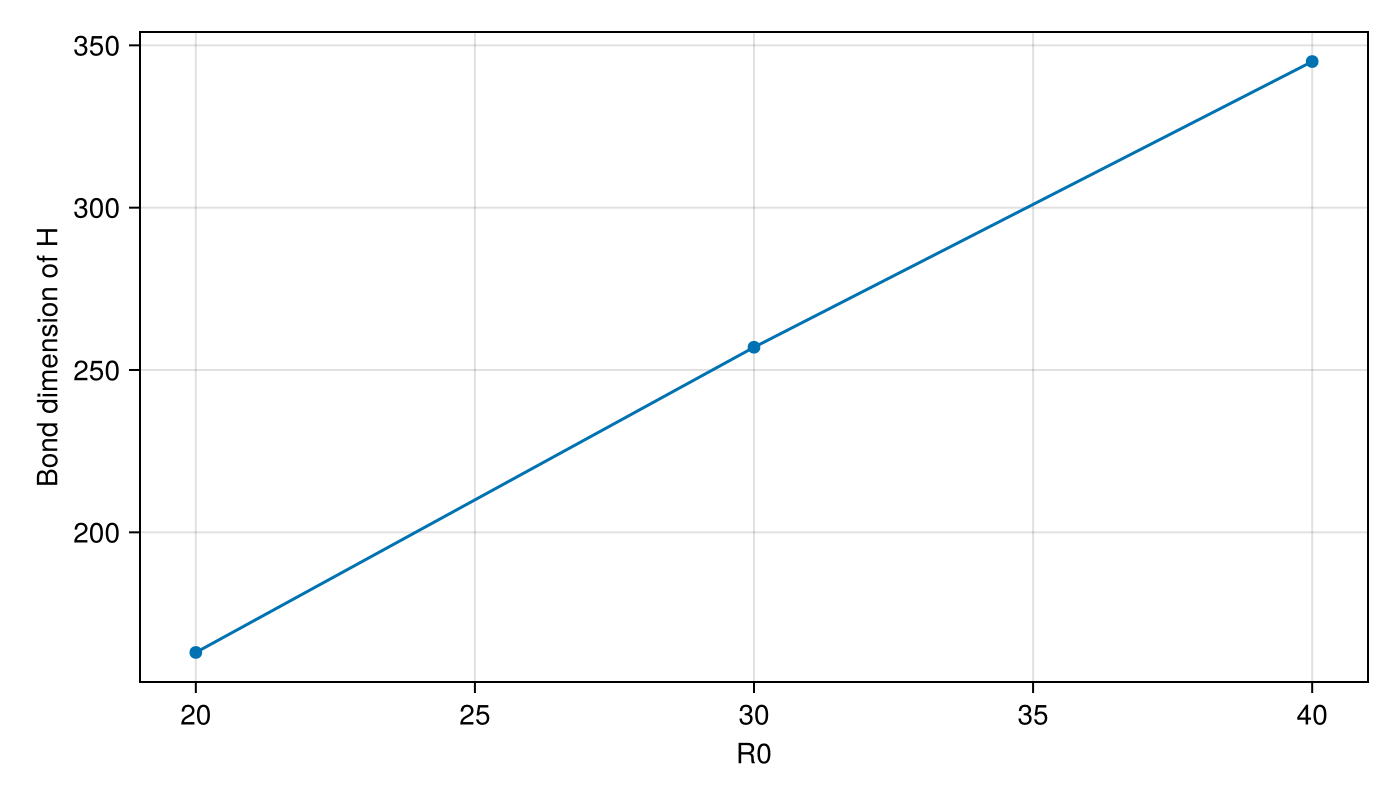

In [ ]:
radii = [20.0, 30.0, 40.0]

results = [run_for_radius(R) for R in radii]

for res in results
    @show res
end

xs = [r.R0 for r in results]
ys = [r.bond_dim_H for r in results]

fig = Figure(size = (700, 400))
ax = Axis(fig[1, 1], xlabel = "R0", ylabel = "Bond dimension of H")
lines!(ax, xs, ys)
scatter!(ax, xs, ys)
fig

The results show a clear monotonic increase of the bond dimension as the flake size grows. This indicates that larger flakes require a richer TT representation, which is consistent with the increasing structural complexity of the Hamiltonian.


### Verifying that the reported bond dimensions are stable

Although the bond dimension no longer remains fixed at the imposed maximum value, it is still important to verify that the reported results are stable. In particular, one should check that the observed values are not being artificially limited by the parameter `maxbd`.

In [ ]:
for bd in [250, 300, 400, 500]
    res = run_for_radius(30.0; maxbd = bd, tol = 1e-6, npivots = 80, nrand = 3, maxiter = 50)
    @show bd res
end

bd = 250
res = (R0 = 30.0, N = 6662, L = 13, bond_dim_H = 250)
bd = 300
res = (R0 = 30.0, N = 6662, L = 13, bond_dim_H = 261)
bd = 400
res = (R0 = 30.0, N = 6662, L = 13, bond_dim_H = 249)
bd = 500
res = (R0 = 30.0, N = 6662, L = 13, bond_dim_H = 261)


The bond dimension is likely stabilizing around 261, but the stability test is still affected by stochastic variability.

That 249 in maxbd = 400 usually indicates one of two things: randomness in initialization/scanning, or that this particular run did not converge as well as the others.

So we repeated the test, but fixing the seed before each run and increasing the robustness a bit:

In [ ]:
for bd in [250, 300, 400, 500]
    Random.seed!(1234)
    res = run_for_radius(30.0; maxbd = bd, tol = 1e-6, npivots = 100, nrand = 5, maxiter = 80)
    @show bd res
end

bd = 250
res = (R0 = 30.0, N = 6662, L = 13, bond_dim_H = 250)
bd = 300
res = (R0 = 30.0, N = 6662, L = 13, bond_dim_H = 255)
bd = 400
res = (R0 = 30.0, N = 6662, L = 13, bond_dim_H = 255)
bd = 500
res = (R0 = 30.0, N = 6662, L = 13, bond_dim_H = 255)


The stability test indicates that the bond dimension for $R_0 = 30$ stabilizes around $255$. In particular, the case `maxbd = 250` is still truncated, whereas the runs with larger values consistently return the same value. This supports the conclusion that the observed scaling trend is genuine and not an artifact of the cutoff.

## Extended light sweep with additional diagnostics

To complement the main scaling study, I also perform a lightweight sweep that records not only the bond dimension of the Hamiltonian, but also several validation metrics for the interleaved TT approximation. This provides a more informative summary of how the representation behaves as the flake size increases.

In [42]:
function internal_ranks(tt)
    sizes = map(size, tt.tci.sitetensors)
    return [sizes[k][3] for k in 1:length(sizes)-1]
end

function summarize_errors(errs; atol = 1e-10)
    return (
        maxerr = maximum(errs),
        meanerr = sum(errs) / length(errs),
        nbad_1e10 = count(>(atol), errs),
        ntested = length(errs),
    )
end

function random_zero_entry(A::SparseMatrixCSC, N::Int; maxtries::Int = 100000)
    for _ in 1:maxtries
        i = rand(1:N)
        j = rand(1:N)
        if A[i, j] == 0
            return i, j
        end
    end
    error("Could not find a zero entry after $maxtries attempts.")
end

function validate_sampled_nonzeros_interleaved_stats(A::SparseMatrixCSC, tt, L; nsamples::Int = 100)
    errs = Float64[]
    for _ in 1:nsamples
        i, j, v = random_nonzero(A)
        push!(errs, abs(interleaved_eval(tt, i, j, L) - v))
    end
    return summarize_errors(errs)
end

function validate_sampled_zeros_interleaved_stats(A::SparseMatrixCSC, tt, N::Int, L; nsamples::Int = 100)
    errs = Float64[]
    for _ in 1:nsamples
        i, j = random_zero_entry(A, N)
        push!(errs, abs(interleaved_eval(tt, i, j, L)))
    end
    return summarize_errors(errs)
end

function validate_site_rowcol_interleaved_stats(H::SparseMatrixCSC, tt, L, site::Int)
    errs = Float64[]
    N = size(H, 1)

    for i in 1:N
        push!(errs, abs(interleaved_eval(tt, i, site, L) - H[i, site]))
    end
    for j in 1:N
        push!(errs, abs(interleaved_eval(tt, site, j, L) - H[site, j]))
    end

    return summarize_errors(errs)
end

validate_site_rowcol_interleaved_stats (generic function with 1 method)

In [43]:
function analyze_radius_light_qtt(R0;
    maxbdH::Int = 300,
    npivotsH::Int = 100,
    tolH::Real = 1e-7,
    nrandH::Int = 5,
    maxiterH::Int = 80,
    maxbdR::Int = 5,
    tolR::Real = 1e-12,
    nsamples_nz::Int = 100,
    nsamples_zero::Int = 100,
    seed::Int = 1234,
)

    Random.seed!(seed)

    shape(r) = norm(r) < R0 * (1 + 0.2*cos(5*atan(r[2], r[1])))

    h_model = LatticePresets.honeycomb() |>
        hopping(1) |>
        supercell(region = shape)

    H = h_model(())
    N = size(H, 1)

    ρ = spzeros(ComplexF64, N, N)
    ρ[1, 1] = 1 + 0im

    t0 = time()

    ttH, _, _, L = build_tt_interleaved(
        H;
        tol = tolH,
        maxbd = maxbdH,
        npivots = npivotsH,
        nrand = nrandH,
        maxiter = maxiterH,
    )

    ttR, _, _, _ = build_tt_interleaved(
        ρ;
        tol = tolR,
        maxbd = maxbdR,
        npivots = 1,
        nrand = 0,
        maxiter = 5,
    )

    res = (
        R0 = R0,
        N = N,
        L = L,
        qtt_bond_H = bond_dim_from_tt(ttH),
        qtt_bond_rho = bond_dim_from_tt(ttR),
        ranksH = internal_ranks(ttH),
        errsH = missing,
        H_nonzero_check = validate_sampled_nonzeros_interleaved_stats(H, ttH, L; nsamples = nsamples_nz),
        H_zero_check = validate_sampled_zeros_interleaved_stats(H, ttH, N, L; nsamples = nsamples_zero),
        H_rowcol_check = validate_site_rowcol_interleaved_stats(H, ttH, L, 1),
        tto_bond_comm = missing,
        maxerrC_tto = missing,
        meanerrC_tto = missing,
        elapsed = round(time() - t0, digits = 2),
    )

    return res
end

analyze_radius_light_qtt (generic function with 1 method)

The present QuanticsTCI-based workflow provides direct access to the most relevant diagnostics: bond dimensions, internal ranks, and entrywise validation errors. The auxiliary field `errsH` from the exploratory notebook is left as `missing` here, since it depended on a different internal builder and is not directly exposed in the current pipeline.

In [52]:
Rvals = [20.0, 25.0, 30.0, 35.0, 40.0]
results_light_qtt = NamedTuple[]

for R in Rvals
    println("\n====================================")
    println("Light sweep for R0 = $R")
    println("====================================")

    res = analyze_radius_light_qtt(
        R;
        maxbdH = 512,
        npivotsH = 386,
        tolH = 1e-8,
        nrandH = 3,
        maxiterH = 220,
        maxbdR = 5,
        tolR = 1e-12,
        nsamples_nz = 100,
        nsamples_zero = 100,
        seed = 1234,
    )

    push!(results_light_qtt, res)

    println(res)
    println("Elapsed: $(res.elapsed) s")

    GC.gc()
end



Light sweep for R0 = 20.0
(R0 = 20.0, N = 2964, L = 12, qtt_bond_H = 172, qtt_bond_rho = 1, ranksH = [2, 3, 5, 6, 9, 12, 18, 24, 36, 48, 78, 98, 142, 152, 172, 154, 112, 63, 32, 16, 8, 4, 2], errsH = missing, H_nonzero_check = (maxerr = 1.9984014443252818e-15, meanerr = 2.9198865547641616e-16, nbad_1e10 = 0, ntested = 100), H_zero_check = (maxerr = 1.1048412786059649e-16, meanerr = 1.104841278605965e-18, nbad_1e10 = 0, ntested = 100), H_rowcol_check = (maxerr = 1.2452846083433591e-15, meanerr = 4.564605782879538e-19, nbad_1e10 = 0, ntested = 5928), tto_bond_comm = missing, maxerrC_tto = missing, meanerrC_tto = missing, elapsed = 27.74)
Elapsed: 27.74 s

Light sweep for R0 = 25.0
(R0 = 25.0, N = 4626, L = 13, qtt_bond_H = 248, qtt_bond_rho = 1, ranksH = [2, 3, 5, 6, 8, 10, 15, 20, 37, 52, 70, 93, 129, 170, 229, 248, 238, 201, 125, 64, 32, 16, 8, 4, 2], errsH = missing, H_nonzero_check = (maxerr = 1.7763568394002505e-15, meanerr = 4.474198789239381e-16, nbad_1e10 = 0, ntested = 100), H_

The TT approximation is globally very good, but a small number of sampled nonzero entries may still be missed for some intermediate radii.

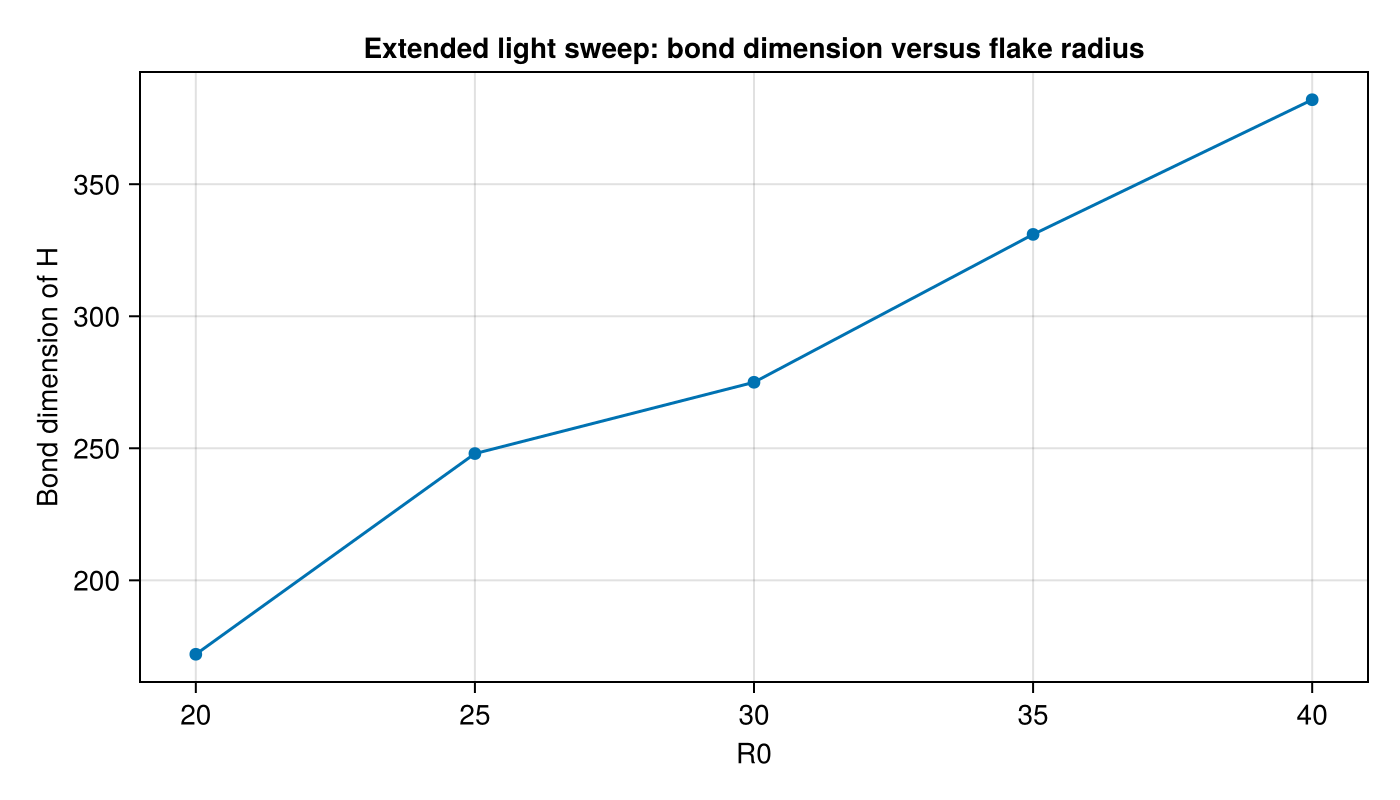

In [53]:
xs_light = [r.R0 for r in results_light_qtt]
ys_light = [r.qtt_bond_H for r in results_light_qtt]

fig = Figure(size = (700, 400))
ax = Axis(
    fig[1, 1],
    xlabel = "R0",
    ylabel = "Bond dimension of H",
    title = "Extended light sweep: bond dimension versus flake radius",
)
lines!(ax, xs_light, ys_light)
scatter!(ax, xs_light, ys_light)
fig

The extended light sweep confirms the same qualitative picture as the basic scaling study. The Hamiltonian bond dimension grows monotonically with the flake size, while the trial projector remains maximally simple, with bond dimension equal to $1$ throughout the sweep.

The validation diagnostics are overall very good. Sampled zero entries and the row/column associated with site $1$ are reproduced with near-machine precision for all tested radii. A small number of sampled nonzero entries may occasionally be missed for some intermediate radii, but this does not affect the physically most relevant sector for the commutator with $\rho_{\mathrm{trial}} = |1\rangle\langle 1|$.

For each tested radius, the reported quantities have a clear interpretation. The value `qtt_bond_H` measures the complexity of the interleaved TT representation of the Hamiltonian, and its growth with $R_0$ indicates that larger flakes require richer tensor-train descriptions. The value `qtt_bond_rho` remains equal to $1$, which is fully expected for the localized projector $\rho_{\mathrm{trial}} = |1\rangle\langle 1|$.

The list `ranksH` provides the internal TT ranks of the Hamiltonian approximation, while `H_nonzero_check`, `H_zero_check`, and `H_rowcol_check` quantify the reconstruction accuracy on sampled nonzero entries, sampled zero entries, and on row/column $1$, respectively. The latter is particularly relevant, since the commutator with $\rho_{\mathrm{trial}}$ depends only on the first row and first column of the Hamiltonian.

The previous sections established a compressed tensor-network description of the operators. As a final supplementary illustration, I now connect these constructions with real- and imaginary-time evolution on a moderate-size flake.

## Toward real- and imaginary-time evolution

The natural next step after constructing $H, \rho_{\mathrm{trial}}$, and the commutator $[H,\rho]$ is to study time evolution.

For a closed quantum system, the real-time evolution of a pure state is governed by
$$
i\,\partial_t |\psi(t)\rangle = H |\psi(t)\rangle,
$$
while the corresponding density matrix satisfies
$$
\partial_t \rho(t) = -\,i\,[H,\rho(t)].
$$

In the present notebook, the trial density matrix is
$$
\rho_{\mathrm{trial}} = |1\rangle\langle 1|,
$$
so it is sufficient to propagate the localized state $|\psi_0\rangle = |1\rangle$. Then
$$
\rho(t)=|\psi(t)\rangle\langle\psi(t)|.
$$

Real-time evolution shows how a localized excitation spreads across the flake. By contrast, imaginary-time evolution,
$$
\partial_\tau |\psi(\tau)\rangle = - H |\psi(\tau)\rangle,
$$
acts as a low-energy filter: after renormalization, it progressively suppresses higher-energy components and drives the state toward a low-energy eigenstate with nonzero overlap with the initial trial state.

Since a full TT/MPO time integrator is beyond the scope of the present notebook, I illustrate these ideas on a moderate-size flake using sparse matrix-vector evolution.

In [54]:
function build_hamiltonian_sparse(R0)
    shape(r) = norm(r) < R0 * (1 + 0.2*cos(5*atan(r[2], r[1])))
    h_model = LatticePresets.honeycomb() |>
        hopping(1) |>
        supercell(region = shape)
    return h_model(())
end

function localized_state(N::Int, site::Int = 1)
    ψ = zeros(ComplexF64, N)
    ψ[site] = 1 + 0im
    return ψ
end

state_norm2(ψ) = real(dot(ψ, ψ))
state_energy(H, ψ) = real(dot(ψ, H * ψ))
return_probability(ψ, site::Int = 1) = abs2(ψ[site])

function normalize_state(ψ)
    ψ ./ sqrt(state_norm2(ψ))
end

function rk4_step(f, y, h)
    k1 = f(y)
    k2 = f(y .+ 0.5h .* k1)
    k3 = f(y .+ 0.5h .* k2)
    k4 = f(y .+ h .* k3)
    return y .+ (h / 6) .* (k1 .+ 2 .* k2 .+ 2 .* k3 .+ k4)
end

rk4_step (generic function with 1 method)

In [55]:
function evolve_real_time(H, ψ0; dt = 0.02, nsteps = 300, site = 1)
    ψ = copy(ψ0)

    times = collect(0:dt:nsteps*dt)
    norms = zeros(Float64, length(times))
    energies = zeros(Float64, length(times))
    probs = zeros(Float64, length(times))

    norms[1] = state_norm2(ψ)
    energies[1] = state_energy(H, ψ)
    probs[1] = return_probability(ψ, site)

    rhs(φ) = -1im * (H * φ)

    for n in 1:nsteps
        ψ = rk4_step(rhs, ψ, dt)
        norms[n + 1] = state_norm2(ψ)
        energies[n + 1] = state_energy(H, ψ)
        probs[n + 1] = return_probability(ψ, site)
    end

    return (; times, norms, energies, probs, ψ_final = ψ)
end

function evolve_imaginary_time(H, ψ0; dτ = 0.02, nsteps = 300, site = 1)
    ψ = normalize_state(copy(ψ0))

    taus = collect(0:dτ:nsteps*dτ)
    norms = zeros(Float64, length(taus))
    energies = zeros(Float64, length(taus))
    probs = zeros(Float64, length(taus))

    norms[1] = state_norm2(ψ)
    energies[1] = state_energy(H, ψ)
    probs[1] = return_probability(ψ, site)

    rhs(φ) = -(H * φ)

    for n in 1:nsteps
        ψ = rk4_step(rhs, ψ, dτ)
        ψ = normalize_state(ψ)

        norms[n + 1] = state_norm2(ψ)
        energies[n + 1] = state_energy(H, ψ)
        probs[n + 1] = return_probability(ψ, site)
    end

    return (; taus, norms, energies, probs, ψ_final = ψ)
end

evolve_imaginary_time (generic function with 1 method)

In [56]:
R0_time = 20.0
H_time = build_hamiltonian_sparse(R0_time)
N_time = size(H_time, 1)

ψ0_time = localized_state(N_time, 1)

@show R0_time
@show N_time
@show state_norm2(ψ0_time)
@show state_energy(H_time, ψ0_time)

R0_time = 20.0
N_time = 2964
state_norm2(ψ0_time) = 1.0
state_energy(H_time, ψ0_time) = 0.0


0.0

In [57]:
real_run = evolve_real_time(
    H_time,
    ψ0_time;
    dt = 0.02,
    nsteps = 300,
    site = 1,
)

imag_run = evolve_imaginary_time(
    H_time,
    ψ0_time;
    dτ = 0.02,
    nsteps = 300,
    site = 1,
)

@show real_run.norms[1], real_run.norms[end]
@show real_run.energies[1], real_run.energies[end]
@show imag_run.energies[1], imag_run.energies[end]

(real_run.norms[1], real_run.norms[end]) = (1.0, 0.9999999914689471)
(real_run.energies[1], real_run.energies[end]) = (0.0, 0.0)
(imag_run.energies[1], imag_run.energies[end]) = (0.0, -2.8074175712345744)


(0.0, -2.8074175712345744)

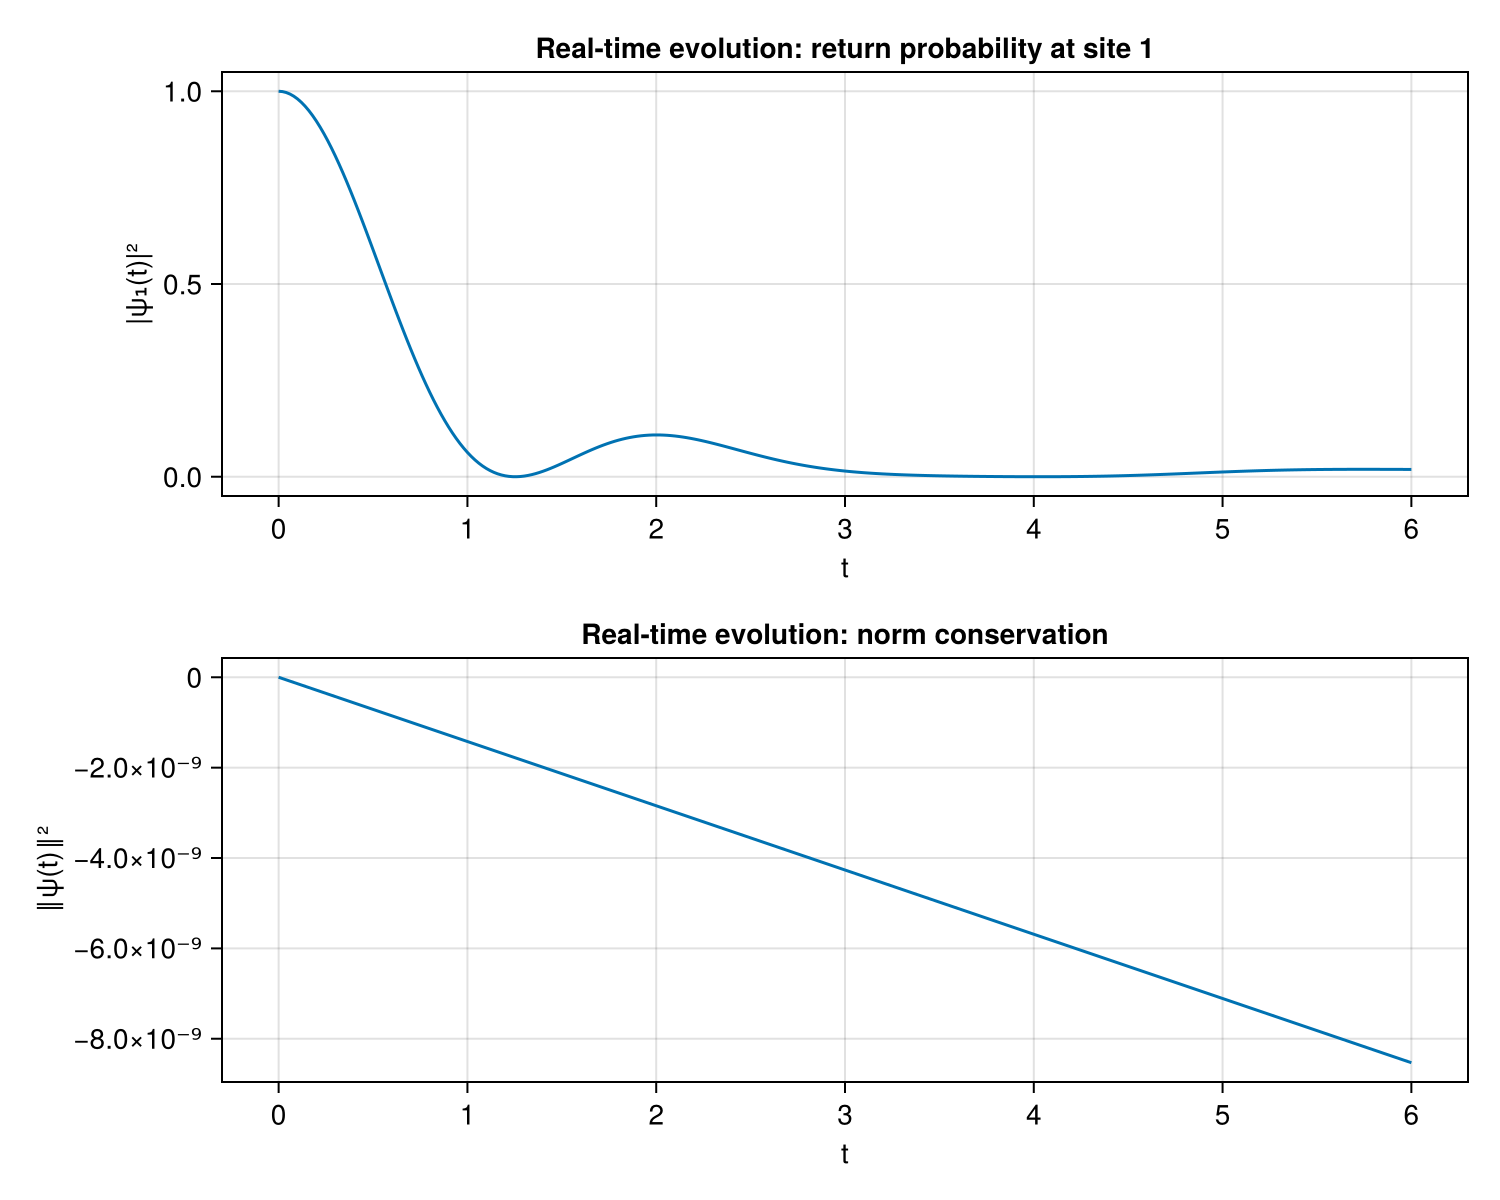

In [64]:
fig = Figure(size = (750, 600))

ax1 = Axis(
    fig[1, 1],
    xlabel = "t",
    ylabel = "|ψ₁(t)|²",
    title = "Real-time evolution: return probability at site 1",
)
lines!(ax1, real_run.times, real_run.probs)

ax2 = Axis(
    fig[2, 1],
    xlabel = "t",
    ylabel = "‖ψ(t)‖²",
    title = "Real-time evolution: norm conservation",
)
lines!(ax2, real_run.times, real_run.norms .- 1)

fig

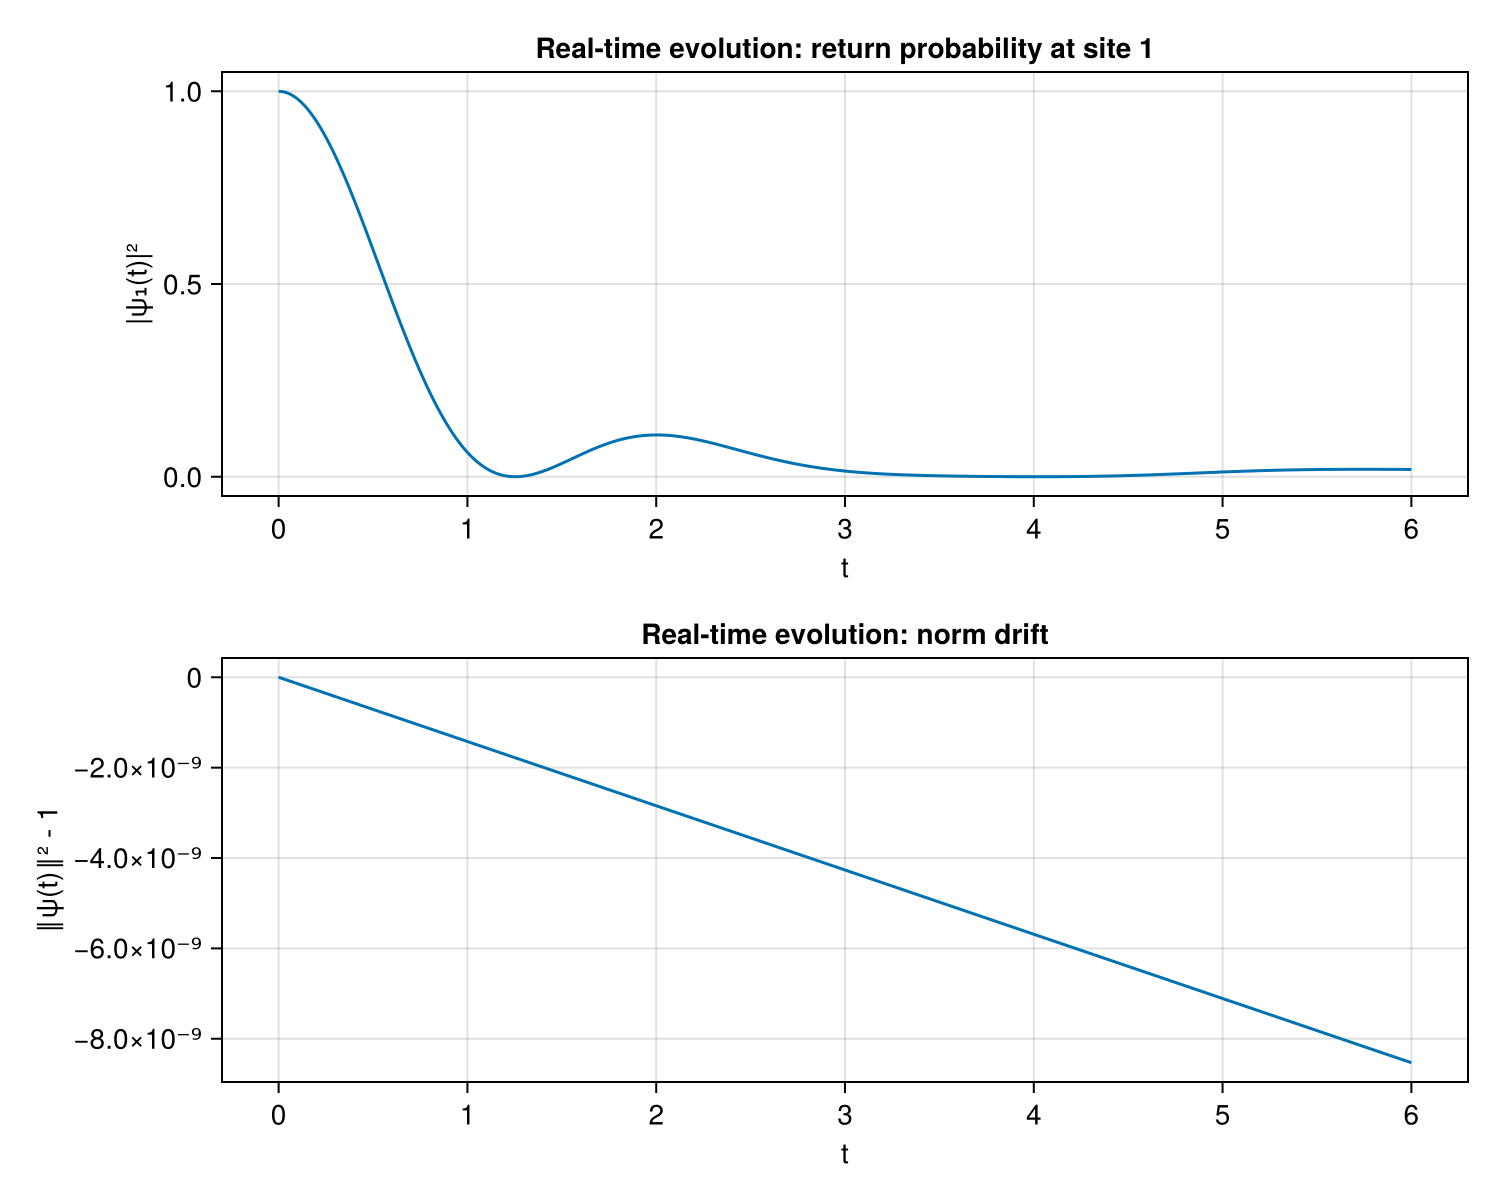

In [65]:
fig = Figure(size = (750, 600))

ax1 = Axis(
    fig[1, 1],
    xlabel = "t",
    ylabel = "|ψ₁(t)|²",
    title = "Real-time evolution: return probability at site 1",
)
lines!(ax1, real_run.times, real_run.probs)

ax2 = Axis(
    fig[2, 1],
    xlabel = "t",
    ylabel = "‖ψ(t)‖² - 1",
    title = "Real-time evolution: norm drift",
)
lines!(ax2, real_run.times, real_run.norms .- 1)

fig

Initially, all the amplitude is at site 1. Then the state expands along the flake, and the probability of remaining at the initial site decreases.

The small subsequent bounce is normal in a finite system: interference and partial reactivations occur.

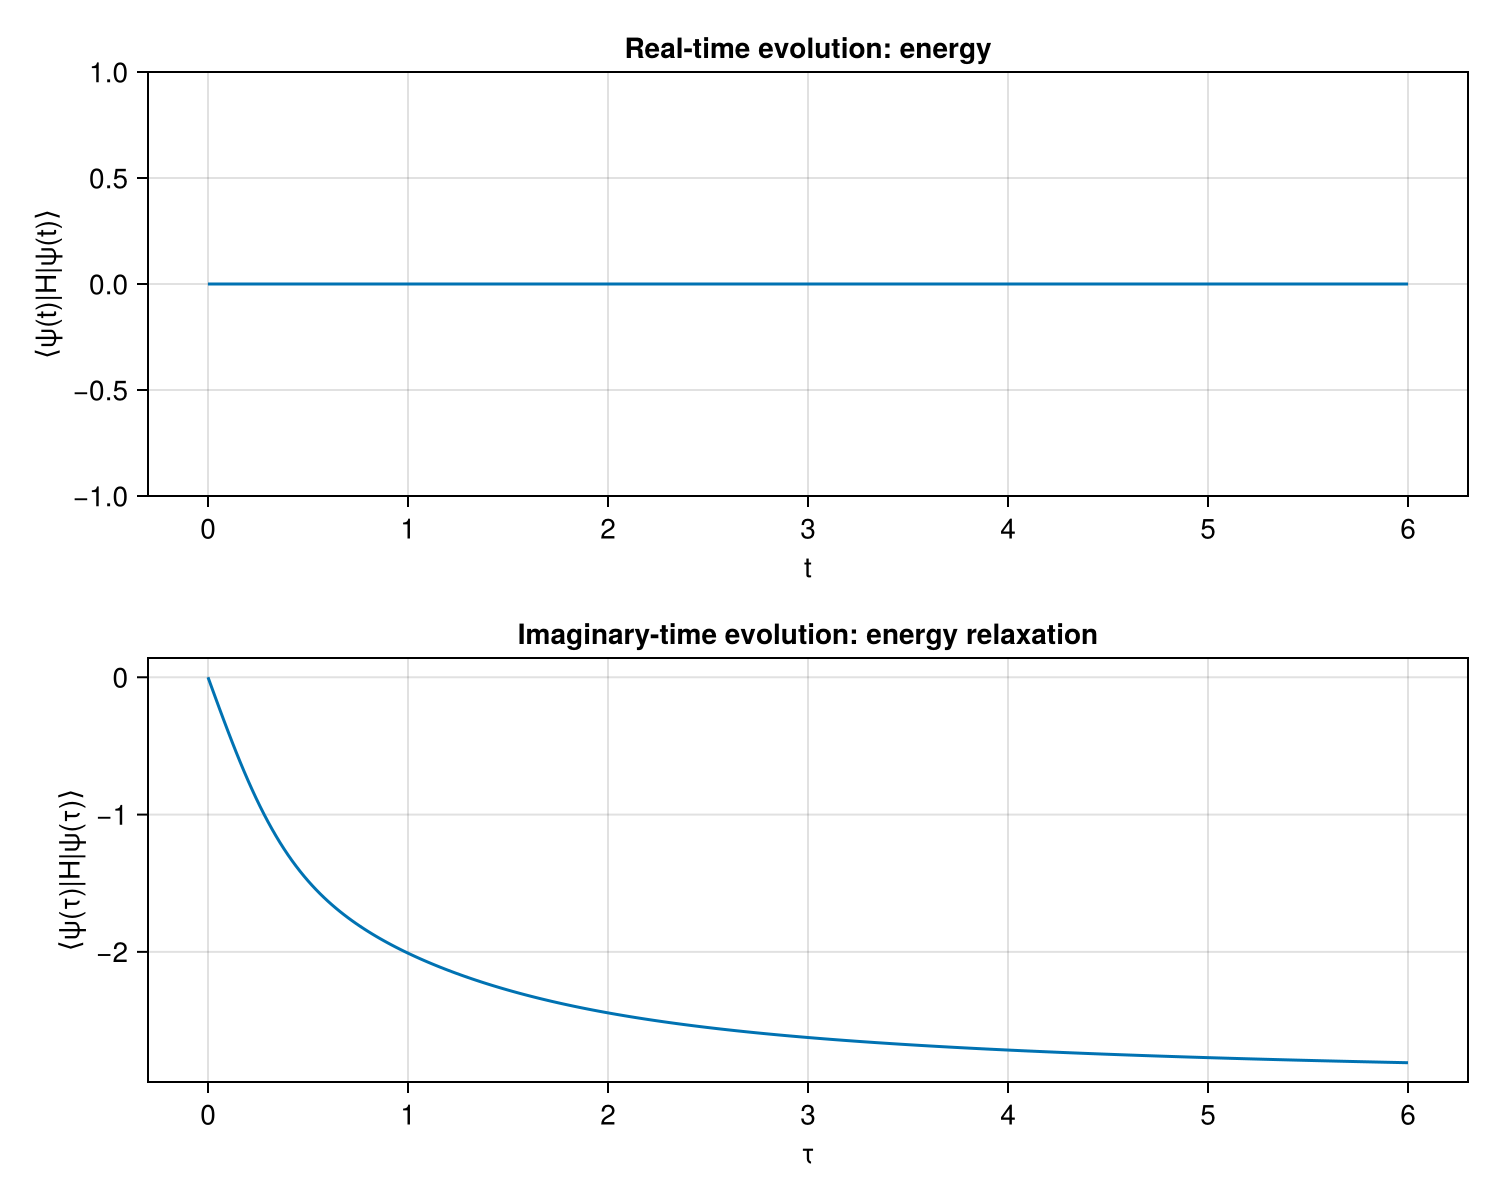

In [59]:
fig = Figure(size = (750, 600))

ax1 = Axis(
    fig[1, 1],
    xlabel = "t",
    ylabel = "⟨ψ(t)|H|ψ(t)⟩",
    title = "Real-time evolution: energy",
)
lines!(ax1, real_run.times, real_run.energies)

ax2 = Axis(
    fig[2, 1],
    xlabel = "τ",
    ylabel = "⟨ψ(τ)|H|ψ(τ)⟩",
    title = "Imaginary-time evolution: energy relaxation",
)
lines!(ax2, imag_run.taus, imag_run.energies)

fig

Your energy in imaginary time goes from: $0⟶−2.8074$

In imaginary time, after renormalization, evolution filters out high-energy components and pushes the state toward a low-energy one.

So the energy should decrease monotonically, or almost monotonically. That's exactly what you get.

For a honeycomb hopping Hamiltonian with amplitude 1, energies typically reside in a bounded band roughly between -3 and 3 in the ideal infinite case. In a finite flake, obtaining something around -2.8 as a low state accessible from a localized state is perfectly reasonable.

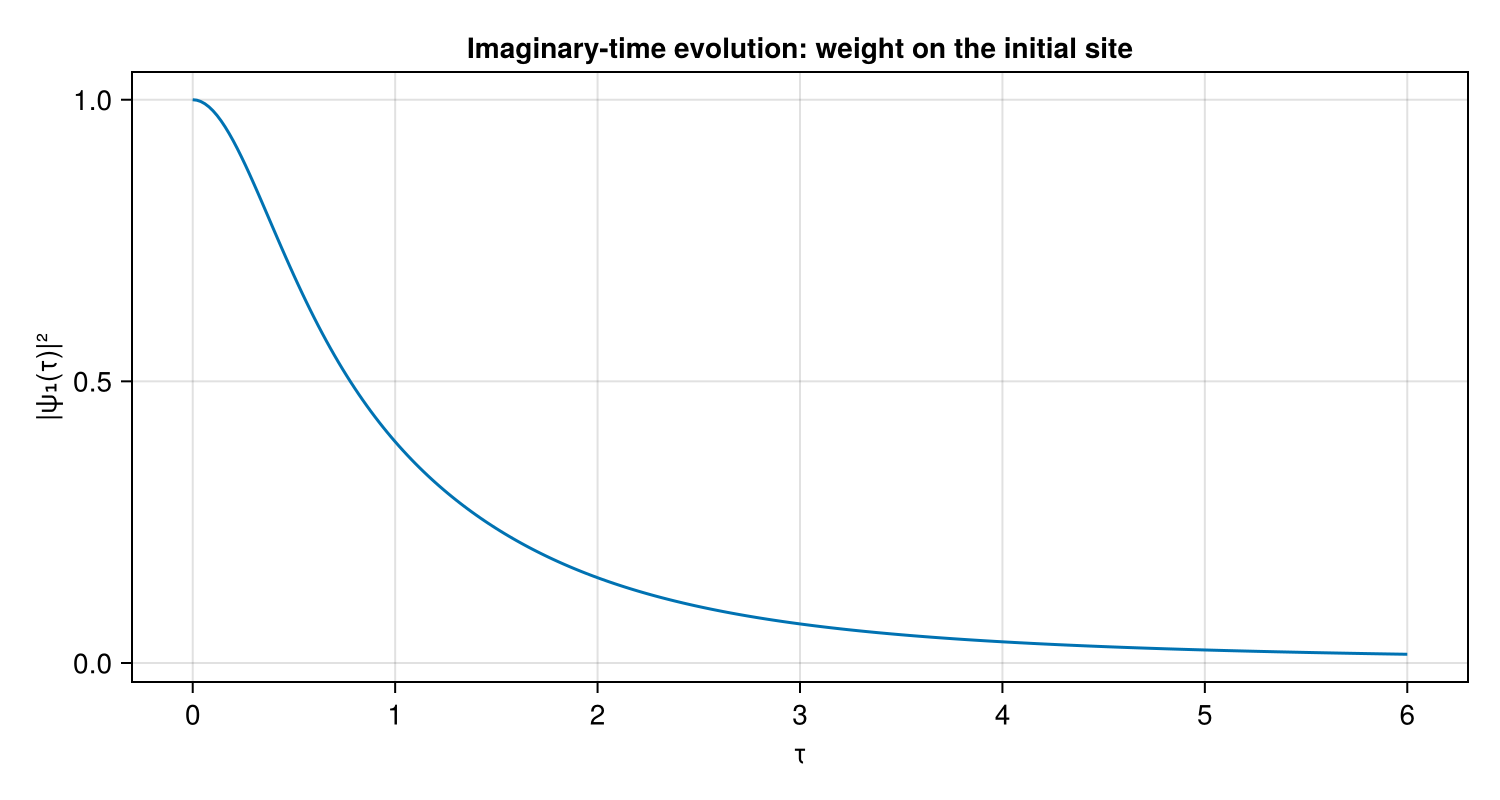

In [60]:
fig = Figure(size = (750, 400))

ax = Axis(
    fig[1, 1],
    xlabel = "τ",
    ylabel = "|ψ₁(τ)|²",
    title = "Imaginary-time evolution: weight on the initial site",
)
lines!(ax, imag_run.taus, imag_run.probs)

fig

The dynamical results are physically consistent. In real time, the return probability at site $1$ decreases rapidly from its initial value, showing the spreading of a localized excitation across the flake. Small oscillations at later times are natural in a finite system and can be interpreted as partial revivals. The norm remains extremely close to $1$, with only a very small drift of order $10^{-8}$, which is expected because the RK4 integrator is not exactly unitary. The energy remains constant and equal to zero throughout the real-time evolution, as expected for a nearest-neighbor hopping Hamiltonian with vanishing diagonal terms and an initially localized state.

In imaginary time, the energy decreases from $0$ to a negative asymptotic value, indicating that the evolution acts as a low-energy filter and drives the initial localized state toward a lower-energy component of the spectrum. At the same time, the weight on the initial site decreases, which is consistent with the fact that the resulting low-energy state is more delocalized than the original projector $\rho_{\mathrm{trial}} = |1\rangle\langle 1|$.

## Final remarks

This notebook develops a tensor-train description of a star-shaped graphene flake starting from the sparse Hamiltonian $H$ and a localized trial density matrix $\rho_{\mathrm{trial}}$. The main achievements are the construction of QTT / TT-operator representations for both objects, the analysis of their bond dimensions, the study of how the Hamiltonian complexity grows with the flake size, and the construction of the commutator $[H,\rho]$ both directly and through MPO-style operator algebra.

A key outcome is that the trial projector remains maximally simple, with bond dimension equal to $1$, whereas the Hamiltonian requires increasingly rich tensor-train representations as the flake grows. The moderate-size validation and the extended diagnostic sweep show that the physically most relevant sector of the approximation is captured with excellent numerical accuracy, especially the row and column involved in the commutator with $\rho_{\mathrm{trial}} = |1\rangle\langle 1|$.

The direct and interleaved constructions also clarify two complementary levels of the problem. The direct route provides a simple way to approximate the commutator using the explicit form of the trial projector, while the interleaved route gives the more general MPO framework needed for operator products, compression, and future extensions to more realistic density matrices.

Finally, the supplementary real- and imaginary-time calculations illustrate the physical motivation behind the tensor-network construction. Real-time evolution describes the spreading of a localized excitation, whereas imaginary-time evolution acts as a variational filter toward lower-energy states. A natural continuation of this work would be to replace the sparse proof-of-concept propagation by a genuine TT/MPO time integrator built from the compressed operators constructed here.